In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Load Data

In [4]:
from src.data_loader import load_wti_data
from src.preprocessing import clean_wti_data

df = load_wti_data()

df = clean_wti_data(df)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367
2021-06-04,69.620003,69.760002,68.330002,68.910004,326250
2021-06-07,69.230003,70.000000,68.930000,69.519997,365621


# Daily Returns

In [5]:
from src.metrics import (
    calculate_daily_return
)

df["daily_return"] = (
    calculate_daily_return(df)
)

df.head()

Price,Close,High,Low,Open,Volume,daily_return
Date,,,,,,
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,NaN
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,0.016391
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,-0.000291
2021-06-04,69.620003,69.760002,68.330002,68.910004,326250,0.011772
2021-06-07,69.230003,70.000000,68.930000,69.519997,365621,-0.005602


In [6]:
df["daily_return"].describe()

count    1256.000000
mean        0.000525
std         0.025261
min        -0.164143
25%        -0.013499
50%         0.001489
75%         0.014903
max         0.122084
Name: daily_return, dtype: float64

Questions:

1. Average daily return?
2. Largest gain?
3. Largest loss?

# Volatility

In [8]:
from src.metrics import (
    rolling_volatility
)

df["volatility_20"] = (
    rolling_volatility(
        df["daily_return"]
    )
)

df.head()

Price,Close,High,Low,Open,Volume,daily_return,volatility_20
Date,,,,,,,
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,NaN,NaN
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,0.016391,NaN
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,-0.000291,NaN
2021-06-04,69.620003,69.760002,68.330002,68.910004,326250,0.011772,NaN
2021-06-07,69.230003,70.000000,68.930000,69.519997,365621,-0.005602,NaN


In [9]:
df["volatility_20"].describe()

count    1237.000000
mean        0.023221
std         0.010309
min         0.009910
25%         0.015983
50%         0.021290
75%         0.025908
max         0.067892
Name: volatility_20, dtype: float64

# Moving Averages

In [10]:
from src.metrics import (
    moving_average
)

df["MA20"] = moving_average(
    df["Close"],
    20
)

df["MA50"] = moving_average(
    df["Close"],
    50
)

df["MA100"] = moving_average(
    df["Close"],
    100
)

# Drawdowns

In [12]:
from src.metrics import (
    calculate_drawdown
)

df["drawdown"] = (
    calculate_drawdown(
        df["Close"]
    )
)

In [13]:
df["drawdown"].min()

np.float64(-0.5531931946539221)

In [14]:
df.to_csv(
    "../data/processed/wti_timeseries_features.csv"
)

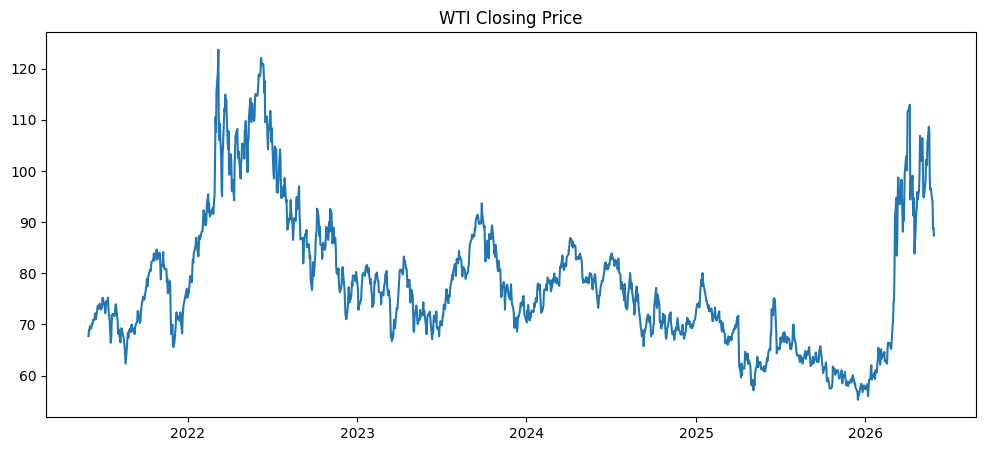

In [15]:
from src.visualization import (
    plot_close_price
)

plot_close_price(df)